<a href="https://colab.research.google.com/github/NiroNithy/Personal_Portfolio/blob/Research/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
#LOAD THE DATA
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

df=pd.read_csv('/content/BOC_Dataset.csv',encoding='ISO-8859-1')
df

,content,at,appVersion
0,It's time to do the Revamp ð´,2024-12-01T17:38:26,1.2.27
1,Bad UX experience and Bad UI,2024-11-30T09:53:50,1.2.27
2,The worst app I ever used,2024-11-30T03:47:02,1.2.27
3,This app needs a revision soon. All other comp...,2024-11-29T03:49:26,1.2.27
4,Worst banking app ever. Not user friendly at a...,2024-11-25T23:17:11,1.2.27
...,...,...,...
706,Not perfect but it does the job,2023-10-02T05:29:54,1.2.27
707,I think 2000 years OLD app develepors workinga.,2023-10-02T02:40:43,1.2.27
708,Great app.. easy to access all services. Pleas...,2023-09-30T19:58:34,1.2.27
709,ð¥ð,2023-09-29T03:17:55,1.2.27


In [ ]:
# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Preprocessing function
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    words = word_tokenize(text.lower())  # Tokenize and convert to lowercase
    return ' '.join(word for word in words if word.isalnum() and word not in stop_words)

In [ ]:
# Apply preprocessing to the content column
df['cleaned_content'] = df['content'].apply(preprocess_text)

In [ ]:
df

,content,at,appVersion,cleaned_content
0,It's time to do the Revamp ð´,2024-12-01T17:38:26,1.2.27,time revamp
1,Bad UX experience and Bad UI,2024-11-30T09:53:50,1.2.27,bad ux experience bad ui
2,The worst app I ever used,2024-11-30T03:47:02,1.2.27,worst app ever used
3,This app needs a revision soon. All other comp...,2024-11-29T03:49:26,1.2.27,app needs revision soon competitors adopted bi...
4,Worst banking app ever. Not user friendly at a...,2024-11-25T23:17:11,1.2.27,worst banking app ever user friendly leading b...
...,...,...,...,...
706,Not perfect but it does the job,2023-10-02T05:29:54,1.2.27,perfect job
707,I think 2000 years OLD app develepors workinga.,2023-10-02T02:40:43,1.2.27,think 2000 years old app develepors workinga
708,Great app.. easy to access all services. Pleas...,2023-09-30T19:58:34,1.2.27,great app easy access services please change b...
709,ð¥ð,2023-09-29T03:17:55,1.2.27,


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#Initialize VADER Sentiment Analyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
sia = SentimentIntensityAnalyzer()

In [ ]:
#Take Sentiment Score
def classify_sentiment(score):
  if score >= 0.05:
    return 'positive'
  elif score <= 0.05:
    return 'negative'
  else:
    return 'netural'

#new output column as sentiment score(value)
df['sentiment_score'] = df['content'].apply(lambda x:sia.polarity_scores(x)['compound'])
df['sentiment'] = df['sentiment_score'].apply(classify_sentiment)

In [ ]:
#Filter rows with negative sentiment
negative_reviews = df[df['sentiment'] == 'negative']

In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
negative,547
positive,164


In [ ]:
# Convert text to a TF-IDF representation
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
tfidf_dtm = tfidf_vectorizer.fit_transform(negative_reviews['cleaned_content'])

In [ ]:
# Apply LDA for topic modeling
lda = LatentDirichletAllocation(n_components=2, random_state=42)  # Assume 2 topics (UI, UX)
lda.fit(tfidf_dtm)

LatentDirichletAllocation(n_components=2, random_state=42)

In [ ]:
# Extract keywords for each topic
def get_top_keywords(model, feature_names, n_top_words):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        topics[f"Topic {topic_idx + 1}"] = [feature_names[i] for i in topic.argsort()[-n_top_words:]]
    return topics

n_top_words = 20
feature_names = tfidf_vectorizer.get_feature_names_out()
topics = get_top_keywords(lda, feature_names, n_top_words)

In [ ]:
print("Identified Topics with Keywords:")
for topic, keywords in topics.items():
   print(f"{topic}: {', '.join(keywords)}")

Identified Topics with Keywords:
Topic 1: mobile, times, loading, user, lanka, sri, open, useless, service, boc, login, log, ca, work, connect, bank, server, time, app, slow
Topic 2: horrible, transfer, update, seen, access, need, really, error, properly, use, online, experience, application, poor, bad, used, working, banking, worst, app


In [ ]:
#Assign the most probable topic to each review
negative_reviews['topic'] = lda.transform(tfidf_dtm).argmax(axis=1)

<ipython-input-17-1c6ee9867e2a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews['topic'] = lda.transform(tfidf_dtm).argmax(axis=1)


In [ ]:
# Map topic numbers to labels
topic_labels = {0: 'UI', 1: 'UX'}
negative_reviews['classification'] = negative_reviews['topic'].map(topic_labels)

<ipython-input-18-6f27e2f65528>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews['classification'] = negative_reviews['topic'].map(topic_labels)


In [ ]:
negative_reviews

,content,at,appVersion,cleaned_content,sentiment_score,sentiment,topic,classification
0,It's time to do the Revamp ð´,2024-12-01T17:38:26,1.2.27,time revamp,0.0000,negative,0,UI
1,Bad UX experience and Bad UI,2024-11-30T09:53:50,1.2.27,bad ux experience bad ui,-0.7906,negative,1,UX
2,The worst app I ever used,2024-11-30T03:47:02,1.2.27,worst app ever used,-0.6249,negative,1,UX
3,This app needs a revision soon. All other comp...,2024-11-29T03:49:26,1.2.27,app needs revision soon competitors adopted bi...,0.0000,negative,1,UX
4,Worst banking app ever. Not user friendly at a...,2024-11-25T23:17:11,1.2.27,worst banking app ever user friendly leading b...,-0.7527,negative,0,UI
...,...,...,...,...,...,...,...,...
705,Worst banking app in Sri Lanka,2023-10-02T11:23:30,1.2.27,worst banking app sri lanka,-0.6249,negative,0,UI
706,Not perfect but it does the job,2023-10-02T05:29:54,1.2.27,perfect job,-0.2498,negative,0,UI
707,I think 2000 years OLD app develepors workinga.,2023-10-02T02:40:43,1.2.27,think 2000 years old app develepors workinga,0.0000,negative,1,UX
709,ð¥ð,2023-09-29T03:17:55,1.2.27,,0.0000,negative,0,UI


In [ ]:
# Split the data into training and testing sets
X = tfidf_dtm.toarray()
Y = negative_reviews['classification'].apply(lambda x: 0 if x == 'UI' else 1)

In [ ]:
# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [ ]:
# Define KNN model
knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:

# Train the KNN model
knn.fit(X_train, Y_train)

# Predict on the test set
Y_pred = knn.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(Y_test, Y_pred)

# Calculate the MSE (Mean Squared Error)
mse = mean_squared_error(Y_test, Y_pred)

print(f"KNN Accuracy: {accuracy:.2f}")
print(f"KNN Mean Squared Error (MSE): {mse:.2f}")

KNN Accuracy: 0.73
KNN Mean Squared Error (MSE): 0.27


In [ ]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Classification report
print(classification_report(Y_test, Y_pred, target_names=['UI', 'UX']))

# Or individual scores
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

              precision    recall  f1-score   support

          UI       0.68      0.97      0.80        61
          UX       0.91      0.43      0.58        49

    accuracy                           0.73       110
   macro avg       0.80      0.70      0.69       110
weighted avg       0.78      0.73      0.70       110

Precision: 0.91
Recall: 0.43
F1 Score: 0.58


In [ ]:
import collections

# Count labels
print("Train set distribution:", collections.Counter(Y_train))
print("Test set distribution:", collections.Counter(Y_test))

Train set distribution: Counter({0: 244, 1: 193})
Test set distribution: Counter({0: 61, 1: 49})


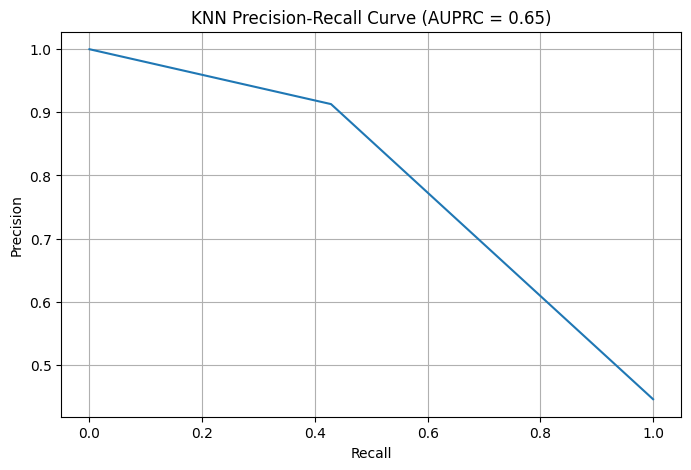

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Get prediction probabilities (before thresholding)
Y_probs = knn.predict(X_test).flatten()

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(Y_test, Y_probs)
auprc = average_precision_score(Y_test, Y_probs)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 5))
plt.plot(recall, precision)
plt.title(f'KNN Precision-Recall Curve (AUPRC = {auprc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

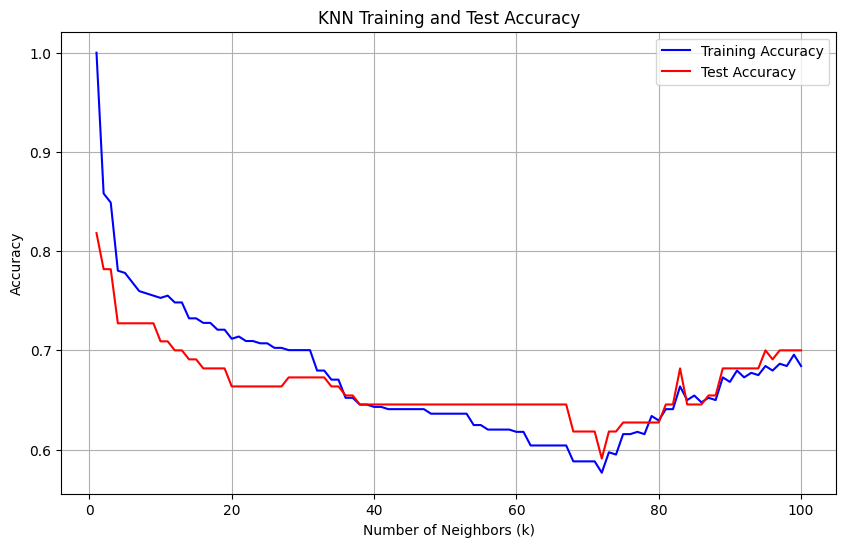

Best k: 5
Final Test Accuracy with k=5: 0.73
Final Training Accuracy with k=5: 0.78


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, mean_squared_error

# Split the data into training and testing sets
X = tfidf_dtm.toarray()
Y = negative_reviews['classification'].apply(lambda x: 0 if x == 'UI' else 1)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Lists to store the accuracies for each iteration
train_accuracies = []
test_accuracies = []

# Train and evaluate the model for different values of k (1 to 20 neighbors)
for k in range(1, 101):  # k can vary from 1 to 20, you can adjust the range as needed
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)  # Train the model

    # Predict on both the training and test sets
    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)

    # Calculate training and test accuracies
    train_acc = accuracy_score(Y_train, train_pred)
    test_acc = accuracy_score(Y_test, test_pred)

    # Append the results
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plot the training and test accuracies
plt.figure(figsize=(10, 6))
plt.plot(range(1, 101), train_accuracies, label='Training Accuracy', color='blue')
plt.plot(range(1, 101), test_accuracies, label='Test Accuracy', color='red')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Training and Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Print final accuracies for the best k
best_k = test_accuracies.index(max(test_accuracies)) + 5
print(f"Best k: {best_k}")
print(f"Final Test Accuracy with k={best_k}: {test_accuracies[best_k-1]:.2f}")
print(f"Final Training Accuracy with k={best_k}: {train_accuracies[best_k-1]:.2f}")
